## 测试用例一

In [ ]:
import matplotlib
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.image import imread

import HMFF
from tests import plot_options as opt

matplotlib.rcParams.update(opt.default_rcParams)

In [ ]:
import yaml

with open('tests/test_info.yaml', 'r') as f:
    test_info = yaml.safe_load(f)

In [ ]:
def plot_data(process, impl, ffs=("f+", "f0", "fT"), ffs_tex=(r"$f_+$", r"$f_0$", r"$f_T$")):
    # 读取测试信息
    infos = test_info[process][impl]["form factors"][ffs[1]]
    ffs_impl = HMFF.formfactors[process].get_impl(impl)
    ffs_func = [ffs_impl.form_factor_function(ff) for ff in ffs]

    # 得到qsq的数据列表，并计算形状因子数据
    qsq = np.linspace(infos["qsq_min"], infos["qsq_max"], infos["qsq_steps"])
    y_data = [ff_func(qsq) for ff_func in ffs_func]

    # 开始绘图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    for ii in range(len(ffs)):
        ax1.plot(qsq, y_data[ii], label=ffs_tex[ii])

    ax1.set_xlim(infos["qsq_min"], infos["qsq_max"])
    ax1.set_ylim(infos["f_min"], infos["f_max"])
    ax1.set_xlabel(r"$q^2$")
    ax1.legend()

    img = imread(infos["ref_figure_path"])
    ax2.imshow(img)
    ax2.axis('off')

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05)

    plt.show()

plot_data("B->eta", "LCSR-pole 2004")

## 测试用例二

In [ ]:
import yaml
from plot_compare import compare

In [2]:
# 基础信息定义
process = "B->eta"
impl = "LCSR-pole 2004"
with open("tests/test_info_P_P.yaml", "r") as f:
    test_info = yaml.safe_load(f)

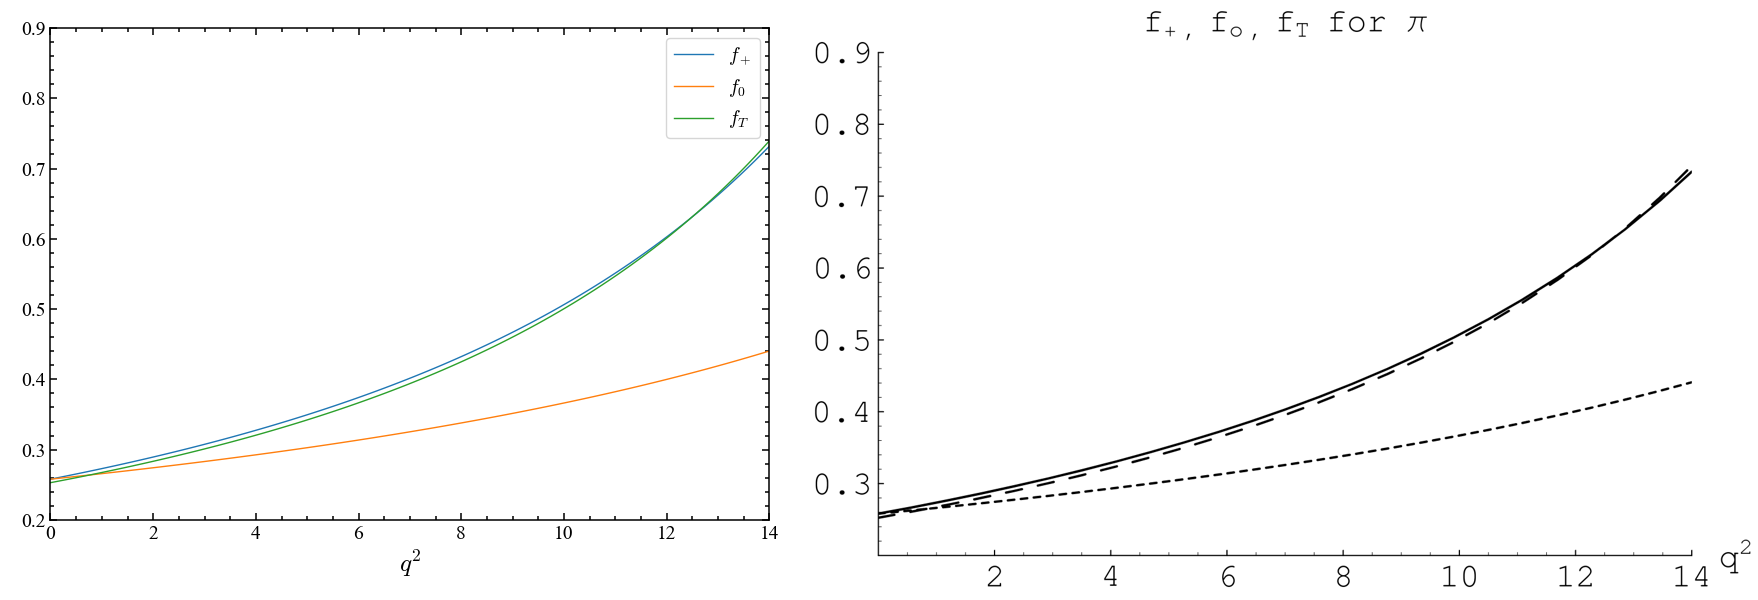

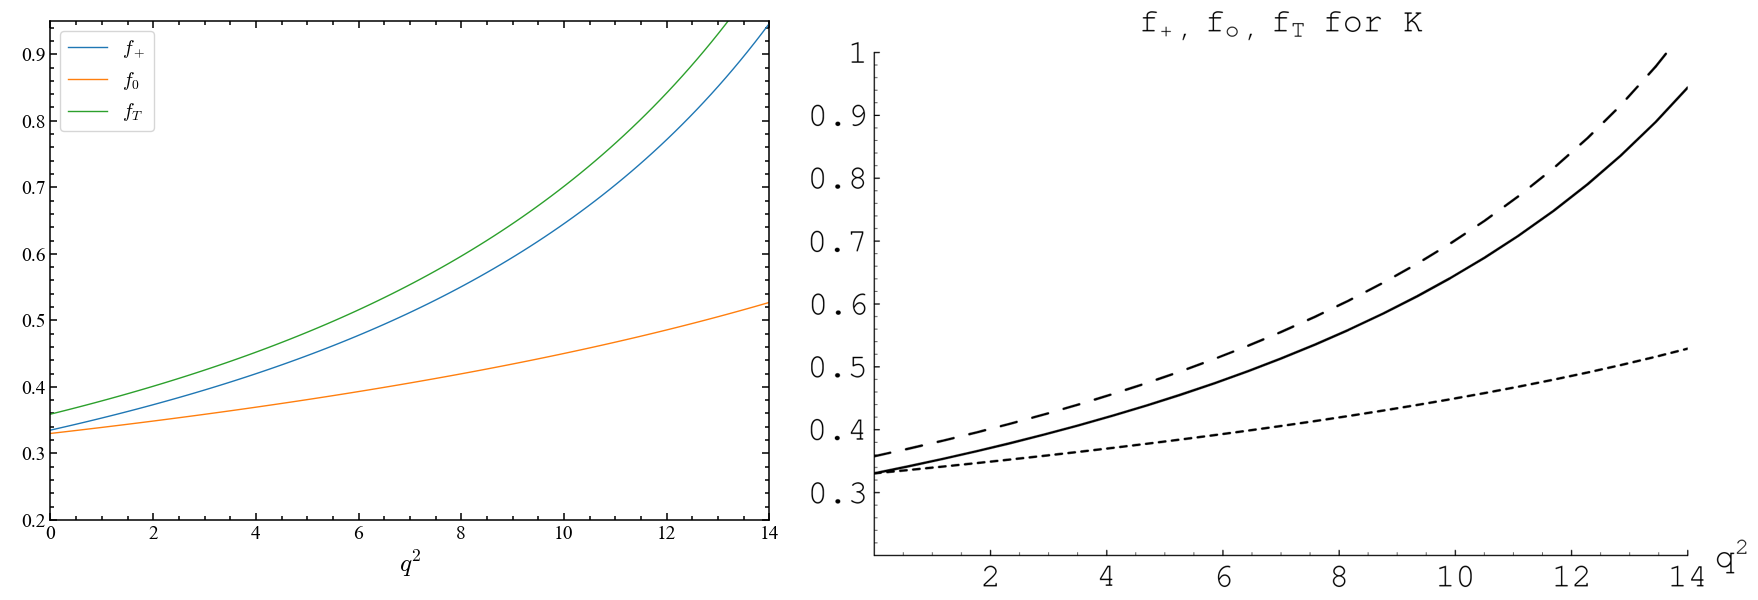

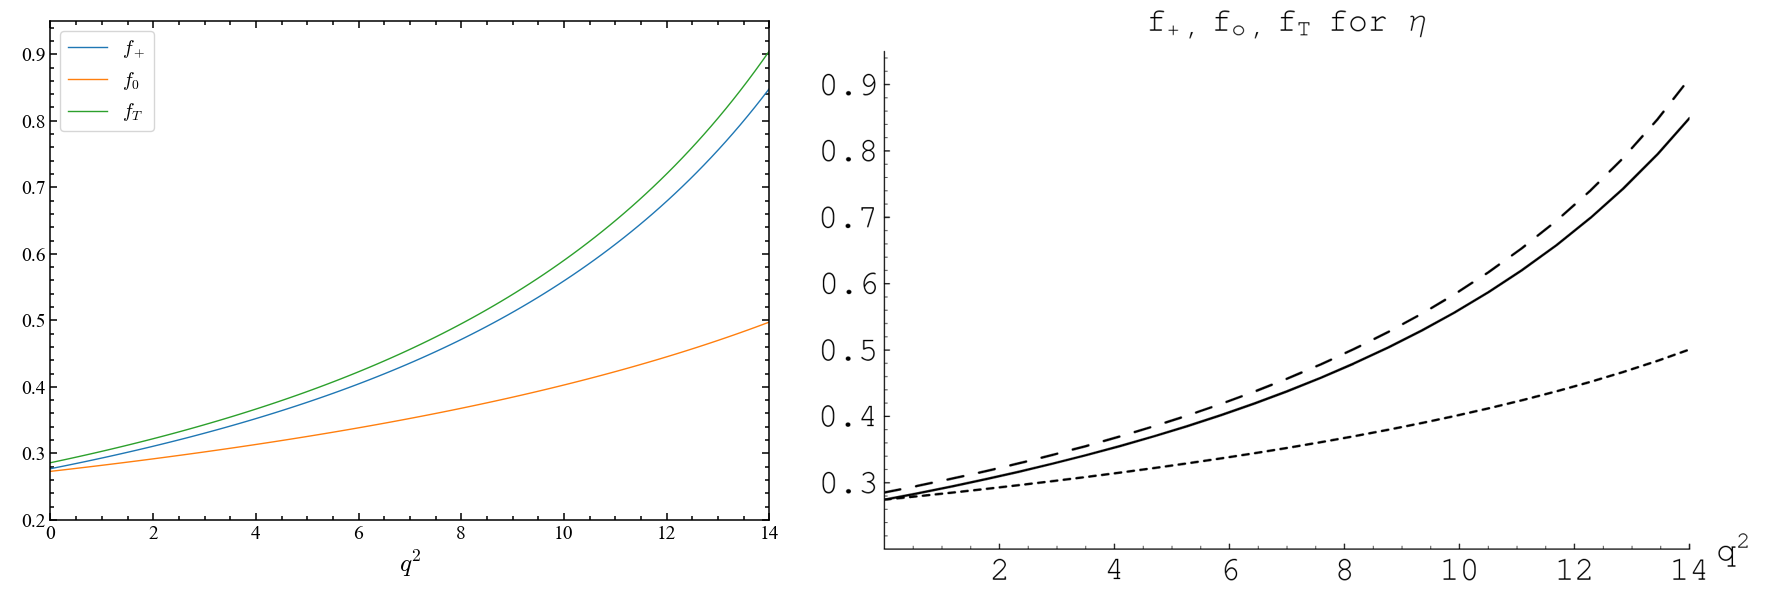

In [3]:
compare("B->pi", "LCSR-pole 2004", test_info)
compare("B->K", "LCSR-pole 2004", test_info)
compare("B->eta", "LCSR-pole 2004", test_info)

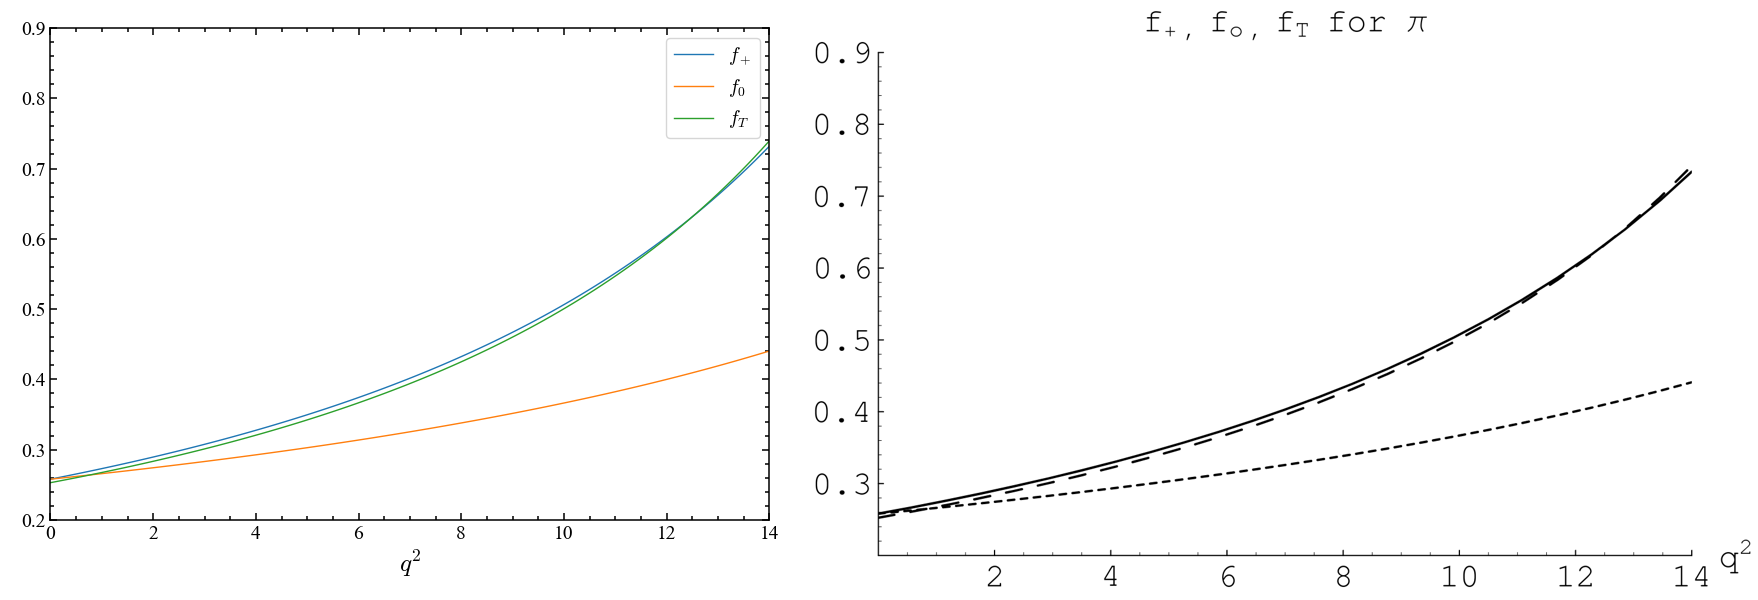